<a href="https://colab.research.google.com/github/kanishkapawar29-code/houseprice_predict/blob/main/house_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries
import numpy as np
import pandas as pd

In [2]:
# Import ML libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

In [3]:
# Load dataset
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [4]:
# Checking features
print("Shape:", X.shape)
print("Features:", data.feature_names)

Shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [5]:
# Display data
print(X.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [6]:
# Log transform
y = np.log1p(y)

In [8]:
# Data preprocessing
# Check BEFORE scaling
print("Before Scaling:\n")
print(X.head())

# Apply scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data into DataFrame for better viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Check AFTER scaling
print("\nAfter Scaling:\n")
print(X_scaled_df.head())

Before Scaling:

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

After Scaling:

     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  2.344766  0.982143  0.628559  -0.153758   -0.974429 -0.049597  1.052548   
1  2.332238 -0.607019  0.327041  -0.263336    0.861439 -0.092512  1.043185   
2  1.782699  1.856182  1.155620  -0.049016   -0.820777 -0.025843  1.038503   
3  0.932968  1.856182  0.156966  -0.049833   -0.766028 -0.050329  1.038503   
4 -0.012881  1.856182  0.3447

In [9]:
# Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [10]:
# Check shapes
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


In [11]:
# Check features name
feature_names = list(data.feature_names)
print(feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [12]:
# Apply PCA
pca = PCA(n_components=8)   # keep full information
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original shape:", X.shape)
print("Reduced shape:", X_train_pca.shape)

Original shape: (20640, 8)
Reduced shape: (16512, 8)


In [13]:
# Use ML model
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train_pca, y_train)

y_pred = np.expm1(model.predict(X_test_pca))
y_test_actual = np.expm1(y_test)
print("R2:", r2_score(y_test_actual, y_pred))

R2: 0.7499567898268924


In [14]:
# Calucalte accuracy
r2 = r2_score(y_test_actual, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7499567898268924


In [15]:
# Calucalte error
mae = mean_absolute_error(y_test_actual, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.38275304098093


In [16]:
# Show actual vs predicted
for i in range(10):
    print(f"Actual: {y_test_actual[i]*100000:.2f} | Predicted: {y_pred[i]*100000:.2f}")

Actual: 47700.00 | Predicted: 46627.45
Actual: 45800.00 | Predicted: 122515.03
Actual: 500001.00 | Predicted: 423849.97
Actual: 218600.00 | Predicted: 271231.62
Actual: 278000.00 | Predicted: 267277.69
Actual: 158700.00 | Predicted: 167646.98
Actual: 198200.00 | Predicted: 233636.09
Actual: 157500.00 | Predicted: 181021.95
Actual: 340000.00 | Predicted: 238296.44
Actual: 446600.00 | Predicted: 486050.50


In [17]:
# Create comparison table
results = pd.DataFrame({
    "Actual": y_test_actual * 100000,
    "Predicted": y_pred * 100000
})

print(results.head())

     Actual      Predicted
0   47700.0   46627.445312
1   45800.0  122515.031250
2  500001.0  423849.968750
3  218600.0  271231.625000
4  278000.0  267277.687500


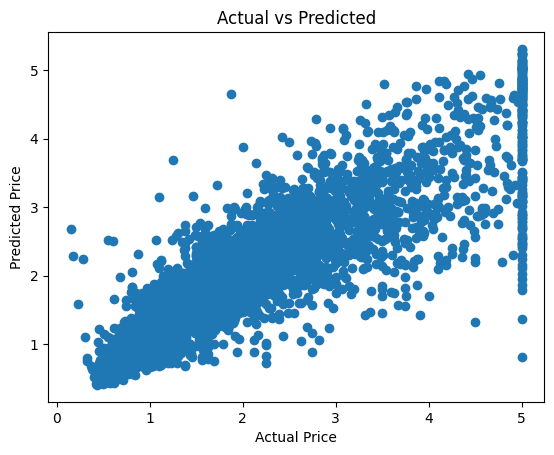

In [18]:
 # Plot the graph
plt.scatter(y_test_actual, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()